In [1]:
!pip install torch torchvision timm scikit-learn matplotlib tqdm

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import timm

import os
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix, classification_report

from tqdm import tqdm

D:\Akash\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

IMAGE_SIZE = 384
BATCH_SIZE = 16
EPOCHS = 40
LR = 1e-4

DATASET_PATH = "Dataset_Split"

print("Device:", DEVICE)

Device: cuda


In [4]:
train_transform = transforms.Compose([
    
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2
    ),
    
    transforms.ToTensor(),
    
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

val_transform = transforms.Compose([
    
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    
    transforms.ToTensor(),
    
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

In [5]:
train_dataset = datasets.ImageFolder(
    os.path.join(DATASET_PATH, "train"),
    transform=train_transform
)

val_dataset = datasets.ImageFolder(
    os.path.join(DATASET_PATH, "val"),
    transform=val_transform
)

test_dataset = datasets.ImageFolder(
    os.path.join(DATASET_PATH, "test"),
    transform=val_transform
)

print("Classes:", train_dataset.classes)

Classes: ['defect', 'good']


In [6]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=4
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4
)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0494049..1.2108063].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..1.8382572].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8952821..0.7925056].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7582842..1.2456646].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9466565..2.343704].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..1.6465361].


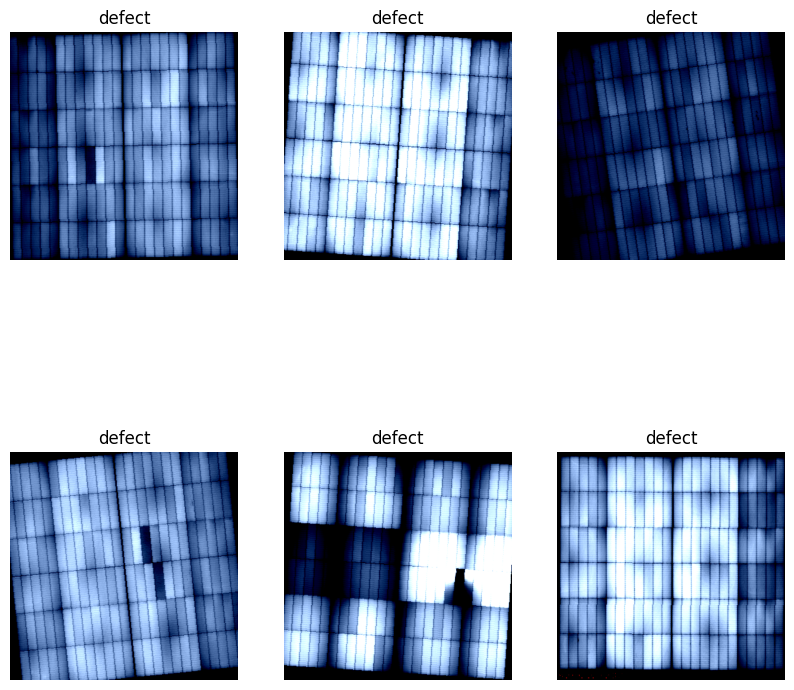

In [7]:
images, labels = next(iter(train_loader))

plt.figure(figsize=(10,10))

for i in range(6):
    
    plt.subplot(2,3,i+1)
    
    img = images[i].permute(1,2,0).numpy()
    
    plt.imshow(img)
    plt.title(train_dataset.classes[labels[i]])
    
    plt.axis("off")

plt.show()

In [8]:
model = timm.create_model(
    "efficientnet_b3",
    pretrained=True,
    num_classes=2
)

model = model.to(DEVICE)

print("Model loaded")

Model loaded


In [9]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(
    model.parameters(),
    lr=LR
)

In [10]:
def train_one_epoch(model, loader):

    model.train()
    
    running_loss = 0
    correct = 0
    total = 0

    loop = tqdm(loader)

    for images, labels in loop:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(images)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, preds = torch.max(outputs, 1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)
        loop.set_postfix(
            loss=loss.item(),
            acc=correct/total
        )

    return running_loss/len(loader), correct/total

In [11]:
def validate(model, loader):

    model.eval()

    running_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item()

            _, preds = torch.max(outputs,1)

            correct += (preds == labels).sum().item()

            total += labels.size(0)

    return running_loss/len(loader), correct/total

In [12]:
best_acc = 0

for epoch in range(EPOCHS):

    print(f"\nEpoch {epoch+1}/{EPOCHS}")

    train_loss, train_acc = train_one_epoch(model, train_loader)
    val_loss, val_acc = validate(model, val_loader)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    
    print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(),"best_el_model.pth")
        print("Best model saved")


Epoch 1/40


100%|███████████████████████████████████████████████████████████████████████████████████████████████████| 91/91 [05:05<00:00,  3.36s/it, acc=0.779, loss=0.612]


Train Loss: 0.7212 | Train Acc: 0.7795
Val Loss: 0.6597 | Val Acc: 0.8097
Best model saved

Epoch 2/40


100%|███████████████████████████████████████████████████████████████████████████████████████████████████| 91/91 [05:03<00:00,  3.34s/it, acc=0.817, loss=0.449]


Train Loss: 0.5368 | Train Acc: 0.8174
Val Loss: 0.2970 | Val Acc: 0.8710
Best model saved

Epoch 3/40


...

Train Loss: 0.0772 | Train Acc: 0.9717
Val Loss: 0.1288 | Val Acc: 0.9613

Epoch 27/40


100%|███████████████████████████████████████████████████████████| 91/91 [04:52<00:00,  3.21s/it, acc=0.97, loss=0.0278]


Train Loss: 0.0777 | Train Acc: 0.9704
Val Loss: 0.1317 | Val Acc: 0.9581

Epoch 28/40


  1%|▋                                                              | 1/91 [00:25<37:38, 25.09s/it, acc=1, loss=0.0047]


KeyboardInterrupt: 

In [13]:
model.load_state_dict(
    torch.load("best_el_model.pth")
)

model.eval()

C:\Users\khush\AppData\Local\Temp\ipykernel_22768\2465903394.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load("best_el_model.pth")


EfficientNet(
  (conv_stem): Conv2d(3, 40, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
  (bn1): BatchNormAct2d(
    40, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
    (drop): Identity()
    (act): SiLU(inplace=True)
  )
  (blocks): Sequential(
    (0): Sequential(
      (0): DepthwiseSeparableConv(
        (conv_dw): Conv2d(40, 40, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=40, bias=False)
        (bn1): BatchNormAct2d(
          40, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
          (drop): Identity()
          (act): SiLU(inplace=True)
        )
        (aa): Identity()
        (se): SqueezeExcite(
          (conv_reduce): Conv2d(40, 10, kernel_size=(1, 1), stride=(1, 1))
          (act1): SiLU(inplace=True)
          (conv_expand): Conv2d(10, 40, kernel_size=(1, 1), stride=(1, 1))
          (gate): Sigmoid()
        )
        (conv_pw): Conv2d(40, 24, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (b

In [14]:
y_true = []
y_pred = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(DEVICE)

        outputs = model(images)

        _, preds = torch.max(outputs,1)

        y_true.extend(labels.numpy())
        y_pred.extend(preds.cpu().numpy())

In [15]:
cm = confusion_matrix(y_true, y_pred)

print(cm)

[[149   8]
 [  4 153]]


In [16]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=train_dataset.classes
    )
)

              precision    recall  f1-score   support

      defect       0.97      0.95      0.96       157
        good       0.95      0.97      0.96       157

    accuracy                           0.96       314
   macro avg       0.96      0.96      0.96       314
weighted avg       0.96      0.96      0.96       314



In [19]:
#------------TESTING ------------
import torch
import timm
from torchvision import transforms
from PIL import Image

# ===== Settings =====
MODEL_PATH = "best_el_model.pth"
# IMAGE_PATH = r"D:\Akash\Dataset\Good EL Image\26356996.jpg"
IMAGE_PATH = r"D:\Akash\Dataset\Defect EL Image\26359978.jpg"
IMAGE_SIZE = 384
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

classes = ['defect','good']

# ===== Image Transform =====
transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

# ===== Load Model =====
model = timm.create_model(
    "efficientnet_b3",
    pretrained=False,
    num_classes=2
)

model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model = model.to(DEVICE)
model.eval()

# ===== Test Function =====
def predict_image(image_path):

    image = Image.open(image_path).convert("RGB")
    image = transform(image).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        output = model(image)
        probs = torch.softmax(output, dim=1)
        pred = torch.argmax(probs,1).item()

    print("Prediction :", classes[pred])
    print("Confidence :", float(probs[0][pred]))

# ===== Run Prediction =====
predict_image(IMAGE_PATH)

C:\Users\khush\AppData\Local\Temp\ipykernel_22768\3360564791.py:33: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(MODEL_PATH, map_location=D

Prediction : defect
Confidence : 0.999951958656311
